> **Angepasste Version für den Methodenvergleich (FCVE).**
> Diese Kopie verwendet den **gemeinsamen Klassifikator** `resnet18_xray_224.pth`
> (torchvision-ResNet-18, trainiert in `Train_ResNet18_XRay.ipynb`, Normierung mean/std = 0.5),
> den auch alle anderen Methoden erklären. Geändert gegenüber dem Original:
> (1) Modell-Factory → torchvision-ResNet-18, (2) Checkpoint-Pfad,
> (3) Normierungskonstanten 0.485/0.229 → 0.5 (inkl. hartkodierter Stellen).
> Die Datei `resnet18_xray_224.pth` muss neben dem Notebook liegen.
> Methode/Losses/Splits/Metriken sind unverändert.
> **Wichtig:** Die alten `fcve_decoder_*.pth` sind gegen den alten Klassifikator trainiert und dürfen nicht geladen werden — dieses Notebook trainiert CFE-Modell und Decoder neu.

# FCVE Training: CFE-Modell + Decoder — Chest X-Ray (No Finding vs. Infiltration)
**Methode:** Faithful Counterfactual Visual Explanations (FCVE) nach Moreira et al. (2025)

## 1. Imports & Konfiguration

In [1]:
import os
import numpy as np
import pandas as pd
from glob import glob
from pathlib import Path
from tqdm import tqdm
from collections import OrderedDict
from functools import partial

import matplotlib.pyplot as plt
import matplotlib.patches as patches
from PIL import Image

import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import Dataset, DataLoader
from torchvision import transforms
from sklearn.model_selection import GroupShuffleSplit

torch.manual_seed(2024)
np.random.seed(2024)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print('Gerät:', DEVICE)

# ── Pfade ─────────────────────────────────────────────────────────────────────
CSV_PATH   = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/Data_Entry_2017.csv'
BBOX_PATH  = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/BBox_List_2017.csv'
IMAGE_GLOB = '/kaggle/input/datasets/organizations/nih-chest-xrays/data/images_*/images/*.png'
from glob import glob as _glob
_ck_name = 'resnet18_xray_224.pth'
PTH_PATH = '/kaggle/input/models/sannap23/xray-cnn-final/pytorch/default/1/resnet18_xray_224.pth'
OUT_DIR    = '/kaggle/working'

IMG_SIZE      = 224
BATCH_SIZE    = 16
IMAGENET_MEAN = [0.5, 0.5, 0.5]
IMAGENET_STD  = [0.5, 0.5, 0.5]
CLASS_NAMES   = {0: 'No Finding', 1: 'Infiltration'}

# CFE-Modell Hyperparameter
CFE_LR     = 1e-4
CFE_EPOCHS = 5
CFE_THRESH = 0.5

# Decoder Hyperparameter
DEC_LR     = 1e-3
DEC_EPOCHS = 10

print('CSV    vorhanden:', os.path.exists(CSV_PATH))
print('BBox   vorhanden:', os.path.exists(BBOX_PATH))
print('Modell vorhanden:', os.path.exists(PTH_PATH))


Gerät: cuda
CSV    vorhanden: True
BBox   vorhanden: True
Modell vorhanden: True


## 2. Datensatz laden & Label-Mapping

In [2]:
all_xray_df = pd.read_csv(CSV_PATH)
all_xray_df['Patient Age'] = all_xray_df['Patient Age'].astype(str).str.rstrip('Y').astype(int)
all_image_paths = {os.path.basename(x): x for x in glob(IMAGE_GLOB)}
all_xray_df['path'] = all_xray_df['Image Index'].map(all_image_paths.get)

def assign_binary_label(finding: str):
    if finding == 'No Finding':
        return 0
    elif 'Infiltration' in finding:
        return 1
    return None

all_xray_df['binary_label'] = all_xray_df['Finding Labels'].map(assign_binary_label)
all_xray_df = all_xray_df.dropna(subset=['binary_label', 'path']).copy()
all_xray_df['binary_label'] = all_xray_df['binary_label'].astype(int)

counts = all_xray_df['binary_label'].value_counts().rename({0: 'No Finding', 1: 'Infiltration'})
print('Klassenverteilung:')
print(counts)


Klassenverteilung:
binary_label
No Finding      60361
Infiltration    19894
Name: count, dtype: int64


## 3. Bounding Boxes laden

In [3]:
bbox_df = pd.read_csv(BBOX_PATH)
bbox_df = bbox_df.rename(columns={'Bbox [x': 'x', 'y': 'y', 'w': 'w', 'h]': 'h'})[
    ['Image Index', 'Finding Label', 'x', 'y', 'w', 'h']]
infiltrate_bbox = bbox_df[bbox_df['Finding Label'] == 'Infiltrate'].copy()
scale = IMG_SIZE / 1024.0
for col in ['x', 'y', 'w', 'h']:
    infiltrate_bbox[col] = infiltrate_bbox[col] * scale
bbox_lookup = infiltrate_bbox.groupby('Image Index').first()[['x', 'y', 'w', 'h']].to_dict('index')
print(f'Infiltrate BBoxes: {len(bbox_lookup)} Bilder')


Infiltrate BBoxes: 123 Bilder


## 4. Train/Test Split (patientenbasiert)

In [4]:
splitter = GroupShuffleSplit(n_splits=1, test_size=0.30, random_state=42)
train_idx, temp_idx = next(splitter.split(all_xray_df, groups=all_xray_df['Patient ID']))
train_df = all_xray_df.iloc[train_idx].reset_index(drop=True)
temp_df  = all_xray_df.iloc[temp_idx].reset_index(drop=True)
splitter2 = GroupShuffleSplit(n_splits=1, test_size=0.50, random_state=42)
val_idx, test_idx = next(splitter2.split(temp_df, groups=temp_df['Patient ID']))
valid_df = temp_df.iloc[val_idx].reset_index(drop=True)
test_df  = temp_df.iloc[test_idx].reset_index(drop=True)
assert len(set(train_df['Patient ID']) & set(test_df['Patient ID'])) == 0
print(f'Train: {len(train_df)}  Val: {len(valid_df)}  Test: {len(test_df)}')


Train: 56768  Val: 11926  Test: 11561


## 5. DataLoader

In [5]:
train_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])
eval_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

class XRayDataset(Dataset):
    def __init__(self, dataframe, transform=None):
        self.df        = dataframe.reset_index(drop=True)
        self.transform = transform
    def __len__(self):
        return len(self.df)
    def __getitem__(self, idx):
        row   = self.df.iloc[idx]
        image = Image.open(row['path']).convert('RGB')
        label = torch.tensor(row['binary_label'], dtype=torch.long)
        fname = row['Image Index']
        if self.transform:
            image = self.transform(image)
        return image, label, fname

# Test-Loader für Auswertung & Metriken
test_dataset = XRayDataset(test_df, transform=eval_transforms)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE,
                          shuffle=True, num_workers=2, pin_memory=False)

# Train-Loader für CFE- und Decoder-Training
train_loader = DataLoader(
    XRayDataset(train_df, transform=train_transforms),
    batch_size=BATCH_SIZE, shuffle=True, num_workers=2, pin_memory=False
)

# Val-Loader für Training-Validation
val_loader = DataLoader(
    XRayDataset(valid_df, transform=eval_transforms),
    batch_size=BATCH_SIZE, shuffle=False, num_workers=2, pin_memory=False
)

print(f'Train-Batches: {len(train_loader)}  Val-Batches: {len(val_loader)}  Test-Batches: {len(test_loader)}')


Train-Batches: 3548  Val-Batches: 746  Test-Batches: 723


In [6]:
class Conv2dAuto(nn.Conv2d):
    def __init__(self, *args, **kwargs):
        super().__init__(*args, **kwargs)
        self.padding = (self.kernel_size[0] // 2, self.kernel_size[1] // 2)

conv3x3 = partial(Conv2dAuto, kernel_size=3, bias=False)

class ResidualBlock(nn.Module):
    def __init__(self, in_channels, out_channels):
        super().__init__()
        self.in_channels  = in_channels
        self.out_channels = out_channels
        self.blocks   = nn.Identity()
        self.shortcut = nn.Identity()
    def forward(self, x):
        residual = self.shortcut(x) if self.should_apply_shortcut else x
        x = self.blocks(x)
        x += residual
        return x
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.out_channels

class ResNetResidualBlock(ResidualBlock):
    def __init__(self, in_channels, out_channels, expansion=1,
                 downsampling=1, conv=conv3x3, *args, **kwargs):
        super().__init__(in_channels, out_channels)
        self.expansion    = expansion
        self.downsampling = downsampling
        self.conv         = conv
        self.shortcut = (
            nn.Sequential(OrderedDict({
                'conv': nn.Conv2d(self.in_channels, self.expanded_channels,
                                  kernel_size=1, stride=self.downsampling, bias=False),
                'bn':   nn.BatchNorm2d(self.expanded_channels)
            }))
            if self.should_apply_shortcut else None
        )
    @property
    def expanded_channels(self):
        return self.out_channels * self.expansion
    @property
    def should_apply_shortcut(self):
        return self.in_channels != self.expanded_channels

def conv_bn(in_channels, out_channels, conv, *args, **kwargs):
    return nn.Sequential(OrderedDict({
        'conv': conv(in_channels, out_channels, *args, **kwargs),
        'bn':   nn.BatchNorm2d(out_channels)
    }))

class ResNetBasicBlock(ResNetResidualBlock):
    expansion = 1
    def __init__(self, in_channels, out_channels, activation=nn.ReLU, *args, **kwargs):
        super().__init__(in_channels, out_channels, *args, **kwargs)
        self.blocks = nn.Sequential(
            conv_bn(self.in_channels, self.out_channels,
                    conv=self.conv, bias=False, stride=self.downsampling),
            activation(),
            conv_bn(self.out_channels, self.expanded_channels,
                    conv=self.conv, bias=False),
        )

class ResNetLayer(nn.Module):
    def __init__(self, in_channels, out_channels, block=ResNetBasicBlock,
                 n=1, *args, **kwargs):
        super().__init__()
        downsampling = 2 if in_channels != out_channels else 1
        self.blocks = nn.Sequential(
            block(in_channels, out_channels, *args, **kwargs,
                  downsampling=downsampling),
            *[block(out_channels * block.expansion, out_channels,
                    downsampling=1, *args, **kwargs) for _ in range(n - 1)]
        )
    def forward(self, x):
        return self.blocks(x)

class ResNetEncoder(nn.Module):
    def __init__(self, in_channels=3, blocks_sizes=(64, 128, 256, 512),
                 depths=(2, 2, 2, 2), activation=nn.ReLU,
                 block=ResNetBasicBlock, *args, **kwargs):
        super().__init__()
        self.blocks_sizes = blocks_sizes
        self.gate = nn.Sequential(
            nn.Conv2d(in_channels, blocks_sizes[0], kernel_size=7,
                      stride=2, padding=3, bias=False),
            nn.BatchNorm2d(blocks_sizes[0]),
            activation(),
            nn.MaxPool2d(kernel_size=3, stride=2, padding=1)
        )
        self.in_out_block_sizes = list(zip(blocks_sizes, blocks_sizes[1:]))
        self.blocks = nn.ModuleList([
            ResNetLayer(blocks_sizes[0], blocks_sizes[0], n=depths[0],
                        activation=activation, block=block, *args, **kwargs),
            *[ResNetLayer(in_ch * block.expansion, out_ch, n=n,
                          activation=activation, block=block, *args, **kwargs)
              for (in_ch, out_ch), n in zip(self.in_out_block_sizes, depths[1:])]
        ])
    def forward(self, x):
        x = self.gate(x)
        for block in self.blocks:
            x = block(x)
        return x

class ResNetDecoder(nn.Module):
    def __init__(self, in_features, n_classes):
        super().__init__()
        self.avg     = nn.AdaptiveAvgPool2d((1, 1))
        self.decoder = nn.Linear(in_features, n_classes)
    def forward(self, x):
        x = self.avg(x)
        x = x.view(x.size(0), -1)
        x = self.decoder(x)
        return x

class ResNet(nn.Module):
    def __init__(self, in_channels, n_classes, *args, **kwargs):
        super().__init__()
        self.encoder = ResNetEncoder(in_channels, *args, **kwargs)
        self.decoder = ResNetDecoder(
            self.encoder.blocks[-1].blocks[-1].expanded_channels, n_classes
        )
    def forward(self, x):
        x = self.encoder(x)
        x = self.decoder(x)
        return x

def build_classifier():
    # Gemeinsamer Klassifikator: torchvision-ResNet-18 (statt Eigenbau-ResNet)
    import torchvision
    return torchvision.models.resnet18(num_classes=2)

checkpoint  = torch.load(PTH_PATH, map_location=DEVICE, weights_only=False)
classifier  = build_classifier().to(DEVICE)
classifier.load_state_dict(checkpoint.get('model_state_dict', checkpoint))
classifier.eval()
for param in classifier.parameters():
    param.requires_grad = False

print('Klassifikator geladen und eingefroren ✓')
print(f'Test Accuracy: {checkpoint.get("test_accuracy", checkpoint.get("val_acc", "N/A"))}')
print(f'Test AUC:      {checkpoint.get("test_auc", "N/A")}')
print(f'Klassen:      {checkpoint.get("class_names", "N/A")}')

def extract_features(model, images):
    """
    Gibt zurück:
      fmaps : (B, 512, 7, 7) — spatiale Feature Maps (für Decoder)
      z_gap : (B, 512)        — nach Global Average Pooling (für CFE-Modell)
    """
    fmaps_list = []
    hook = model.layer4.register_forward_hook(
        lambda m, i, o: fmaps_list.append(o)
    )
    with torch.no_grad():
        _ = model(images)
    hook.remove()
    fmaps = fmaps_list[0]
    z_gap = F.adaptive_avg_pool2d(fmaps, (1,1)).flatten(1)
    return fmaps, z_gap

with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    fm, zg = extract_features(classifier, dummy)
    print('Feature Maps Shape:', fm.shape)
    print('GAP Vector Shape:  ', zg.shape)

Klassifikator geladen und eingefroren ✓
Test Accuracy: 0.6707032263645013
Test AUC:      N/A
Klassen:      {0: 'No Finding', 1: 'Infiltration'}
Feature Maps Shape: torch.Size([2, 512, 7, 7])
GAP Vector Shape:   torch.Size([2, 512])


## 6. Klassifikator laden (ResNet-18)

In [7]:
class CFEModel(nn.Module):
    """
    Faithful CFE-Modell nach Paper (Tariq et al. 2022, Eq. 1, 5, 6),
    zwei unabhaengige Koepfe (dense_mc / dense_mi).

    ABWEICHUNG vom Paper (dokumentiert): MI-Filter sind SIGNIERT
    (kein ReLU auf h_mi). Grund: Mit ReLU kann der MI-Filter Aktivierungen
    nur ERHOEHEN (g + F_MI, F_MI >= 0). Fuer Klassenwechsel, die ein
    ABSENKEN von Filteraktivierungen erfordern (z.B. Infiltration -> No
    Finding: pathologische Merkmale muessen VERSCHWINDEN), ist das
    strukturell unmoeglich -- der MI-Kopf lernt dann die triviale Loesung,
    ALLE Samples in die eine erreichbare Richtung zu kippen (beobachtet im
    X-Ray-Notebook: MI Flip-Acc konstant = Klassenanteil 75.09%%, alle
    CFE-Vorhersagen = Klasse 1). Signierte MI-Filter machen beide
    Richtungen erreichbar; die L1-Sparsity-Loss wirkt unveraendert ueber
    den Betrag.

    Input:  z_gap (B, 512) -- Feature-Vektor nach Global Average Pooling
    Output: MC-Filter (B, 512) quasi-binaer, MI-Filter (B, 512) signiert
    """
    def __init__(self, n_filters=512):
        super().__init__()
        self.dense_mc = nn.Linear(n_filters, n_filters)   # eigenes d^n fuer MC
        self.dense_mi = nn.Linear(n_filters, n_filters)   # eigenes d^n fuer MI
        self.relu_threshold = 0.5   # t im Paper (ReLU_t, Eq. 1)

    def forward(self, z_gap):
        # -- MC-Filter: ReLU_t(Sigmoid(d^n(z_gap))) -- Paper Eq. 5 --------------
        h_mc = self.dense_mc(z_gap)
        mc_filters = torch.sigmoid(h_mc)
        mc_filters = torch.where(
            mc_filters >= self.relu_threshold,
            mc_filters,
            torch.zeros_like(mc_filters)
        )                                              # (B, 512) -- quasi-binaer

        # -- MI-Filter: SIGNIERT (Abweichung von Eq. 6, s. Docstring) -----------
        mi_filters = self.dense_mi(z_gap)              # (B, 512) -- signiert

        return mc_filters, mi_filters


def apply_mc_filters(z_gap, mc_filters):
    """Wendet MC-Filter an: nur aktivierte Filter bleiben (Paper Eq. 2 -- Hadamard-Produkt g*F_MC)"""
    return z_gap * mc_filters

def apply_mi_filters(z_gap, mi_filters):
    """Wendet MI-Filter an: addiert (signierte) Aenderungen (Paper Eq. 8 -- g + F_MI)"""
    return z_gap + mi_filters

def classify_from_gap(classifier, z_gap_modified):
    """Klassifiziert einen modifizierten GAP-Vektor ueber den Decoder-Head."""
    return classifier.fc(z_gap_modified)   # (B, 2) Logits


print('CFE-Modell Klassen definiert (zwei Koepfe, signierte MI-Filter) OK')


CFE-Modell Klassen definiert (zwei Koepfe, signierte MI-Filter) OK


## 7. CFE-Modell (Paper Eq. 4-6)

In [8]:
cfe_model = CFEModel(n_filters=512).to(DEVICE)
cfe_optimizer = torch.optim.Adam(cfe_model.parameters(), lr=CFE_LR)
cfe_scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    cfe_optimizer, mode='min', factor=0.5, patience=3)

# Klassengewichtung aus Trainingsverteilung (train_df aus Abschnitt 4)
n_neg  = (train_df['binary_label'] == 0).sum()   # No Finding
n_pos  = (train_df['binary_label'] == 1).sum()   # Infiltration
weight = torch.tensor([1.0, float(n_neg) / float(n_pos)], dtype=torch.float32).to(DEVICE)
# KORREKTUR 1: Die MI-Loss arbeitet auf GEFLIPPTEN Targets (1-labels). Die
# Klassengewichte muessen dafuer INVERTIERT werden. Vorher: das 3.01x-Gewicht
# auf Infiltration verstaerkte bei geflippten Targets die ohnehin dominante
# Zielrichtung No Finding -> Infiltration zusaetzlich -- der MI-Kopf lernte
# die triviale Ein-Richtungs-Loesung (Flip-Acc konstant 75.09% = Klassenanteil,
# alle CFE-Vorhersagen = Infiltration).
weight_mi  = torch.tensor([float(n_neg) / float(n_pos), 1.0], dtype=torch.float32).to(DEVICE)
ce_loss    = nn.CrossEntropyLoss(weight=weight)      # fuer MC (Original-Targets)
ce_loss_mi = nn.CrossEntropyLoss(weight=weight_mi)   # fuer MI (geflippte Targets)
print(f'Loss Gewichte MC: No Finding={1.0:.2f}  Infiltration={n_neg/n_pos:.2f}x  |  MI invertiert')

# KORREKTUR 2: LAMBDA_MC von 2.0 auf 0.5 gesenkt. Bei den schwaecheren
# Roentgen-Features kollabierte der MC-Kopf mit lambda=2.0 innerhalb einer
# Epoche vollstaendig (MC-Filter: 0.2 -> 0.0), d.h. z_mc = Nullvektor und
# MC Hold-Acc = Majoritaetsklassen-Anteil. Die Sparsity-Loss dominierte den
# (bei X-Ray schwaecheren) Logits-Gradienten.
LAMBDA_MC = 0.5
LAMBDA_MI = 1.0

# -- Holt die GAP->Logits Gewichte W_{k,c} des eingefrorenen Klassifikators --
W_fc = classifier.fc.weight.detach()   # (2, 512)

def logits_loss_mc(z_gap, mc_filters, labels):
    """
    Paper Eq. 6 -- negative Logits-Loss fuer MC-Filter.
    Erzwingt, dass die ausgewaehlten (sparsen) MC-Filter MAXIMAL zur
    Quellklasse `labels` beitragen (gewichtet mit den FC-Gewichten W_{k,c}).
    """
    W_c = W_fc[labels]                                   # (B, 512)
    contrib = (mc_filters * z_gap) * W_c                 # (B, 512)
    return -contrib.abs().sum(dim=1).mean()

def sparsity_loss(filters):
    return filters.abs().mean(dim=1).mean()

cfe_train_losses = []
cfe_val_losses   = []

print('Starte CFE-Modell Training (zwei Koepfe, signierte MI, Logits- + Sparsity-Loss)...')
print(f'Epochs: {CFE_EPOCHS}  LR: {CFE_LR}  Batch-Size: {BATCH_SIZE}')
print(f'lambda_MC={LAMBDA_MC}  lambda_MI={LAMBDA_MI}')
print('-' * 60)

for epoch in range(1, CFE_EPOCHS + 1):
    # -- Training ------------------------------------------------------
    cfe_model.train()
    total_loss, n_correct, n_total = 0.0, 0, 0

    for images, labels, _ in tqdm(train_loader, desc=f'Ep {epoch:02d}/{CFE_EPOCHS} Train',
                                leave=False):
        images, labels = images.to(DEVICE), labels.to(DEVICE)

        _, z_gap = extract_features(classifier, images)

        mc_filters, mi_filters = cfe_model(z_gap)

        target_labels = 1 - labels

        # -- MC-Loss: L_MC = L_CE + lambda_MC * L_l1 - L_logits -----------------
        z_mc        = apply_mc_filters(z_gap.detach(), mc_filters)
        logits_mc   = classify_from_gap(classifier, z_mc)
        loss_mc_ce  = ce_loss(logits_mc, labels)
        loss_mc_l1  = sparsity_loss(mc_filters)
        loss_mc_log = logits_loss_mc(z_gap.detach(), mc_filters, labels)
        loss_mc     = loss_mc_ce + LAMBDA_MC * loss_mc_l1 - loss_mc_log

        # -- MI-Loss: L_MI = L_CE(invertierte Gewichte) + lambda_MI * L_l1 ------
        z_mi        = apply_mi_filters(z_gap.detach(), mi_filters)
        logits_mi   = classify_from_gap(classifier, z_mi)
        loss_mi_ce  = ce_loss_mi(logits_mi, target_labels)
        loss_mi_l1  = sparsity_loss(mi_filters)
        loss_mi     = loss_mi_ce + LAMBDA_MI * loss_mi_l1

        loss = loss_mc + loss_mi

        cfe_optimizer.zero_grad()
        loss.backward()
        cfe_optimizer.step()

        total_loss += loss.item() * images.size(0)
        preds       = logits_mi.argmax(dim=1)
        n_correct  += (preds == target_labels).sum().item()
        n_total    += images.size(0)

    train_loss = total_loss / n_total
    train_acc  = n_correct  / n_total
    cfe_train_losses.append(train_loss)

    # -- Validation ------------------------------------------------------
    cfe_model.eval()
    val_loss_sum, val_correct, val_total = 0.0, 0, 0
    val_mc_correct = 0
    # NEU: Flip-Acc getrennt pro Richtung tracken, um Ein-Richtungs-Kollaps
    # (triviale Loesung) sofort sichtbar zu machen.
    flip_ok = {0: 0, 1: 0}
    flip_n  = {0: 0, 1: 0}

    with torch.no_grad():
        for images, labels, _ in val_loader:
            images, labels = images.to(DEVICE), labels.to(DEVICE)
            _, z_gap = extract_features(classifier, images)
            mc_filters, mi_filters = cfe_model(z_gap)
            target_labels = 1 - labels

            z_mc      = apply_mc_filters(z_gap, mc_filters)
            logits_mc = classify_from_gap(classifier, z_mc)

            z_mi      = apply_mi_filters(z_gap, mi_filters)
            logits_mi = classify_from_gap(classifier, z_mi)

            loss_mc_ce  = ce_loss(logits_mc, labels)
            loss_mc_l1  = sparsity_loss(mc_filters)
            loss_mc_log = logits_loss_mc(z_gap, mc_filters, labels)
            loss_mc     = loss_mc_ce + LAMBDA_MC * loss_mc_l1 - loss_mc_log

            loss_mi_ce  = ce_loss_mi(logits_mi, target_labels)
            loss_mi_l1  = sparsity_loss(mi_filters)
            loss_mi     = loss_mi_ce + LAMBDA_MI * loss_mi_l1

            val_loss_sum  += (loss_mc + loss_mi).item() * images.size(0)
            preds_mi       = logits_mi.argmax(1)
            val_correct   += (preds_mi == target_labels).sum().item()
            val_mc_correct += (logits_mc.argmax(1) == labels).sum().item()
            val_total     += images.size(0)
            for cls in (0, 1):
                m = labels == cls
                flip_n[cls]  += m.sum().item()
                flip_ok[cls] += (preds_mi[m] == target_labels[m]).sum().item()

    val_loss = val_loss_sum / val_total
    val_acc  = val_correct  / val_total
    val_mc_acc = val_mc_correct / val_total
    cfe_val_losses.append(val_loss)
    cfe_scheduler.step(val_loss)

    avg_mc_filters = (mc_filters > 0).float().sum(dim=1).mean().item()
    avg_mi_filters = (mi_filters.abs() > 1e-6).float().sum(dim=1).mean().item()
    flip0 = flip_ok[0] / max(flip_n[0], 1)
    flip1 = flip_ok[1] / max(flip_n[1], 1)

    print(f'Ep {epoch:02d}/{CFE_EPOCHS}  '
          f'Train Loss={train_loss:.4f}  '
          f'Val Loss={val_loss:.4f}  '
          f'MI Flip-Acc={val_acc:.4f} (0->1: {flip0:.3f} | 1->0: {flip1:.3f})  '
          f'MC Hold-Acc={val_mc_acc:.4f}  '
          f'MC-Filter={avg_mc_filters:.1f}  MI-Filter={avg_mi_filters:.1f}')

torch.save({
    'model_state_dict': cfe_model.state_dict(),
    'train_losses':     cfe_train_losses,
    'val_losses':       cfe_val_losses,
    'n_filters':        512,
    'cfe_threshold':    CFE_THRESH,
    'lambda_mc':        LAMBDA_MC,
    'lambda_mi':        LAMBDA_MI,
    'dataset':          'xray',
    'class_names':      CLASS_NAMES,
}, os.path.join(OUT_DIR, 'fcve_cfe_model_xray.pth'))
print(f"\nCFE-Modell gespeichert -> {OUT_DIR}/fcve_cfe_model_xray.pth OK")


Loss Gewichte MC: No Finding=1.00  Infiltration=3.01x  |  MI invertiert
Starte CFE-Modell Training (zwei Koepfe, signierte MI, Logits- + Sparsity-Loss)...
Epochs: 5  LR: 0.0001  Batch-Size: 16
lambda_MC=0.5  lambda_MI=1.0
------------------------------------------------------------


Ep 01/5  Train Loss=1.4094  Val Loss=1.4541  MI Flip-Acc=0.7725 (0->1: 0.923 | 1->0: 0.318)  MC Hold-Acc=0.7509  MC-Filter=0.0  MI-Filter=512.0


Ep 02/5  Train Loss=1.3761  Val Loss=1.3870  MI Flip-Acc=0.7675 (0->1: 0.875 | 1->0: 0.444)  MC Hold-Acc=0.7509  MC-Filter=0.0  MI-Filter=512.0


Ep 03/5  Train Loss=1.3671  Val Loss=1.3691  MI Flip-Acc=0.7509 (0->1: 0.823 | 1->0: 0.535)  MC Hold-Acc=0.7509  MC-Filter=0.0  MI-Filter=512.0


Ep 04/5  Train Loss=1.3634  Val Loss=1.3865  MI Flip-Acc=0.7660 (0->1: 0.869 | 1->0: 0.455)  MC Hold-Acc=0.7509  MC-Filter=0.0  MI-Filter=512.0


Ep 05/5  Train Loss=1.3608  Val Loss=1.3656  MI Flip-Acc=0.7148 (0->1: 0.741 | 1->0: 0.635)  MC Hold-Acc=0.7509  MC-Filter=0.0  MI-Filter=512.0

CFE-Modell gespeichert -> /kaggle/working/fcve_cfe_model_xray.pth OK


## 8. Phase 1 — CFE-Modell Training

In [9]:
class SkipDecoder(nn.Module):
    """
    HYBRID-Decoder: nur die FEINSTE Skip-Ebene (f1, 64 Kanaele, Textur/Schaerfe)
    wird durchgereicht; f2/f3 werden weggelassen (wuerden das CF-Signal
    ueberstimmen).

    GRAYSCALE-HEAD (X-Ray): der Decoder gibt nur EINEN Kanal aus, der auf 3
    Kanaele repliziert wird. Roentgenbilder sind Graustufen (R=G=B); ein
    freier 3-Kanal-Head kann divergieren und erzeugt Chroma-Artefakte
    (beobachtet: orange/blaue Flecken). Mit 1-Kanal-Output sind
    Farbartefakte konstruktiv unmoeglich.

    COLOR-PRIOR (KORRIGIERTE INJEKTION): Die Mittelwert-Farbe des Quellbilds
    wird jetzt am ENDE des Decoders injiziert (nach der letzten BatchNorm,
    vor Tanh). Die alte Injektion am ANFANG (auf f4) war wirkungslos, weil
    die 10 nachfolgenden BatchNorm-Schichten per-Kanal-Mittelwerte gerade
    wegnormalisieren -- der Farb-Bias wurde ausgeloescht, der Gruenstich
    blieb (quantitativ: Rekon-G-Kanal 0.64 vs. Original 0.52).
    """
    def __init__(self):
        super().__init__()
        self.up1 = self._up_block(512, 256)   # 7  -> 14   (kein Skip)
        self.up2 = self._up_block(256, 128)   # 14 -> 28   (kein Skip)
        self.up3 = self._up_block(128, 64)    # 28 -> 56   (kein Skip)
        self.up4 = self._up_block(128, 32)    # 56 -> 112  (+ Skip f1: 64+64=128)
        self.up5 = self._up_block(32,  16)    # 112-> 224
        self.color_proj = nn.Linear(3, 1)       # Farb-Bias, injiziert VOR Tanh
        self.out_conv = nn.Conv2d(16, 1, kernel_size=3, padding=1,
                                  padding_mode='reflect')

    def _up_block(self, in_ch, out_ch):
        return nn.Sequential(
            nn.Upsample(scale_factor=2, mode='bilinear', align_corners=False),
            nn.Conv2d(in_ch, out_ch, kernel_size=3, padding=1, padding_mode='reflect'),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
            nn.Conv2d(out_ch, out_ch, kernel_size=3, padding=1, padding_mode='reflect'),
            nn.BatchNorm2d(out_ch), nn.ReLU(inplace=True),
        )

    def forward(self, f4, f1, color_prior=None, f3=None, f2=None):
        # f3/f2 werden bewusst IGNORIERT (Hybrid: nur f1 zaehlt als Skip)
        x = self.up1(f4)
        x = self.up2(x)
        x = self.up3(x)
        x = torch.cat([x, f1], dim=1)
        x = self.up4(x)
        x = self.up5(x)
        y = self.out_conv(x)
        if color_prior is not None:
            # spaete Injektion: Bias liegt HINTER allen BatchNorms
            y = y + self.color_proj(color_prior).view(-1, 1, 1, 1)
        y = torch.tanh(y)
        y = y.repeat(1, 3, 1, 1)   # Graustufen -> 3 Kanaele fuer Downstream-Kompatibilitaet
        return y


def extract_all_features(model, images):
    """Feature Maps aus allen 4 ResNet-Ebenen + GAP-Vektor."""
    feats = {}
    hooks = []
    layer_map = {
        'f1': model.layer1,
        'f2': model.layer2,
        'f3': model.layer3,
        'f4': model.layer4,
    }
    for name, layer in layer_map.items():
        h = layer.register_forward_hook(
            lambda m, i, o, n=name: feats.update({n: o})
        )
        hooks.append(h)
    with torch.no_grad():
        _ = model(images)
    for h in hooks:
        h.remove()
    f1 = feats['f1']
    f2 = feats['f2']
    f3 = feats['f3']
    f4 = feats['f4']
    z_gap = F.adaptive_avg_pool2d(f4, (1,1)).flatten(1)
    return f1, f2, f3, f4, z_gap


decoder = SkipDecoder().to(DEVICE)
with torch.no_grad():
    dummy = torch.zeros(2, 3, IMG_SIZE, IMG_SIZE).to(DEVICE)
    f1, f2, f3, f4, zg = extract_all_features(classifier, dummy)
    out = decoder(f4, f1)   # Hybrid: nur f1 als Skip
    print('Decoder Output:', out.shape)

total_params = sum(p.numel() for p in decoder.parameters())
print(f'Decoder Parameter: {total_params:,}')


Decoder Output: torch.Size([2, 3, 224, 224])
Decoder Parameter: 2,378,549


## 9. Phase 2 — Decoder Definition (SkipDecoder)

In [10]:
dec_optimizer = torch.optim.Adam(decoder.parameters(), lr=DEC_LR)
dec_scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(
    dec_optimizer, T_max=DEC_EPOCHS)
mae_loss = nn.L1Loss()
ce_loss_dec = nn.CrossEntropyLoss()

# ══════════════════════════════════════════════════════════════════════════════
# RESIDUAL-COMPOSITING (Kernkorrektur dieser Version)
#
# Bisher war das CFE-Bild der ROHE Decoder-Output decoder(z_cf). Damit erbt
# das CFE saemtliche Decoder-Artefakte: Unschaerfe, Farbstich, Randstreifen --
# und JEDES Pixel weicht vom Original ab (Sparsity Rate = 1.0, L1 hoch,
# LPIPS/FID schlecht), selbst wenn die klassenrelevante Aenderung winzig ist.
#
# Neu: Das CFE wird als Original + Residual definiert:
#     x_cf = clamp( x + [ decoder(z_cf) - decoder(z_gap) ], 0, 1 )
# Decoder-Artefakte (Tint, Blur, Randstreifen) stecken in BEIDEN Decodings
# und heben sich in der Differenz auf. Uebrig bleibt genau die Aenderung,
# die der CF-Vektor z_cf gegenueber z_gap bewirkt -- als Delta auf dem
# SCHARFEN Original statt auf einer unscharfen Rekonstruktion.
#
# Zusaetzlich: DELTA-SHRINKAGE. Kleine Restdifferenzen (Decoder-Rauschen)
# unterhalb SHRINK_TAU werden hart auf 0 gesetzt -- nur so faellt die
# Sparsity Rate (Metrik-Schwellwert 1e-4!) unter 1.0. Im Training wird der
# Shrink mit Straight-Through-Gradient angewandt, damit Vorwaertspfad
# (geshrinktes Delta) und Metrik-Bedingungen identisch sind, der Gradient
# aber ungehindert fliesst.
# ══════════════════════════════════════════════════════════════════════════════
SHRINK_TAU = 0.02   # Pixel-Deltas < 2% Helligkeit werden genullt

def shrink_delta(delta):
    """Hartes Nullsetzen kleiner Deltas (Inferenz-Form)."""
    return delta * (delta.abs() > SHRINK_TAU).float()

def shrink_delta_st(delta):
    """Shrink mit Straight-Through-Gradient (Trainings-Form)."""
    return delta + (shrink_delta(delta) - delta).detach()

W_REC  = 3.0
W_CLS  = 1.0
W_PROX = 0.5

dec_train_losses = []
dec_val_losses   = []
best_val_flip    = -1.0
best_state       = None

print('Starte Decoder-Training (Residual-Compositing + Best-Checkpoint)...')
print(f'Epochs: {DEC_EPOCHS}  LR: {DEC_LR}  Batch-Size: {BATCH_SIZE}')
print(f'W_REC={W_REC}  W_CLS={W_CLS}  W_PROX={W_PROX}  SHRINK_TAU={SHRINK_TAU}')
print('-' * 60)

def denormalise(tensor):
    """Funktioniert fuer 3D (C,H,W) und 4D (B,C,H,W) Tensoren."""
    if tensor.dim() == 3:
        mean = torch.tensor([0.5, 0.5, 0.5], device=tensor.device).view(3,1,1)
        std  = torch.tensor([0.5, 0.5, 0.5], device=tensor.device).view(3,1,1)
    else:
        mean = torch.tensor([0.5, 0.5, 0.5], device=tensor.device).view(1,3,1,1)
        std  = torch.tensor([0.5, 0.5, 0.5], device=tensor.device).view(1,3,1,1)
    return (tensor * std + mean).clamp(0, 1)

def renormalise(tensor01):
    """[0,1] -> ImageNet-normalisiert, um Composite erneut zu klassifizieren."""
    mean = torch.tensor([0.5, 0.5, 0.5], device=tensor01.device).view(1,3,1,1)
    std  = torch.tensor([0.5, 0.5, 0.5], device=tensor01.device).view(1,3,1,1)
    return (tensor01 - mean) / std

def tanh_to_img(tensor):
    return (tensor + 1.0) / 2.0

cfe_model.eval()
for p in cfe_model.parameters():
    p.requires_grad = False

for epoch in range(1, DEC_EPOCHS + 1):
    # -- Training ------------------------------------------------------
    decoder.train()
    total_loss, n_total = 0.0, 0

    for images, labels, _ in tqdm(train_loader, desc=f'Ep {epoch:02d}/{DEC_EPOCHS} Train',
                                leave=False):
        images = images.to(DEVICE)
        labels = labels.to(DEVICE)
        B = images.size(0)
        f1, f2, f3, f4, z_gap = extract_all_features(classifier, images)
        f1 = f1.detach()
        img01 = denormalise(images)
        cp = img01.mean(dim=[2, 3])   # (B, 3) Ziel-Mittelfarbe

        with torch.no_grad():
            mc_f, mi_f = cfe_model(z_gap)
            z_cf = apply_mi_filters(apply_mc_filters(z_gap, mc_f), mi_f)
            target_cls = 1 - labels

        # -- 1) Basis-Rekonstruktion: z_gap -> Quellbild ----------------------
        f4_base = z_gap.view(B, 512, 1, 1).expand(-1, 512, 7, 7).contiguous()
        recon_base = decoder(f4_base, f1, color_prior=cp)
        loss_rec = mae_loss(tanh_to_img(recon_base), img01)

        # -- 2) Composite: x + geshrinktes Delta -> soll Zielklasse sein ------
        f4_cf = z_cf.view(B, 512, 1, 1).expand(-1, 512, 7, 7).contiguous()
        recon_cf = decoder(f4_cf, f1, color_prior=cp)
        delta = tanh_to_img(recon_cf) - tanh_to_img(recon_base)
        delta = shrink_delta_st(delta)
        comp  = (img01 + delta).clamp(0, 1)
        logits_cf = classifier(renormalise(comp))
        loss_cls  = ce_loss_dec(logits_cf, target_cls)

        # -- 3) Proximity/Sparsity direkt auf dem Delta ------------------------
        loss_prox = delta.abs().mean()

        loss = W_REC * loss_rec + W_CLS * loss_cls + W_PROX * loss_prox

        dec_optimizer.zero_grad()
        loss.backward()
        dec_optimizer.step()
        total_loss += loss.item() * B
        n_total    += B

    train_loss = total_loss / n_total
    dec_train_losses.append(train_loss)
    dec_scheduler.step()

    # -- Validation: Rekonstruktion + COMPOSITE-Flip-Rate -------------------
    decoder.eval()
    val_loss_sum, val_total, val_flip_correct = 0.0, 0, 0

    with torch.no_grad():
        for images, labels, _ in val_loader:
            images = images.to(DEVICE)
            labels = labels.to(DEVICE)
            f1, f2, f3, f4, z_gap = extract_all_features(classifier, images)
            img01 = denormalise(images)
            cp = img01.mean(dim=[2, 3])
            f4_in  = z_gap.view(-1, 512, 1, 1).expand(-1, 512, 7, 7).contiguous()
            recon  = decoder(f4_in, f1, color_prior=cp)
            val_loss_sum += mae_loss(tanh_to_img(recon), img01).item() * images.size(0)

            mc_f, mi_f = cfe_model(z_gap)
            z_cf = apply_mi_filters(apply_mc_filters(z_gap, mc_f), mi_f)
            target_cls = 1 - labels
            f4_cf = z_cf.view(-1, 512, 1, 1).expand(-1, 512, 7, 7).contiguous()
            recon_cf = decoder(f4_cf, f1, color_prior=cp)
            delta = shrink_delta(tanh_to_img(recon_cf) - tanh_to_img(recon))
            comp  = (img01 + delta).clamp(0, 1)
            preds = classifier(renormalise(comp)).argmax(dim=1)
            val_flip_correct += (preds == target_cls).sum().item()
            val_total += images.size(0)

    val_loss = val_loss_sum / val_total
    val_flip_rate = val_flip_correct / val_total
    dec_val_losses.append(val_loss)

    # -- Best-Checkpoint nach Val-Flip-Rate (Fix fuer Oszillation:
    #    im Fire-Lauf schwankte die Flip-Rate zwischen 0.81 und 0.95 und der
    #    LETZTE Checkpoint war ein schlechter) ------------------------------
    marker = ''
    if val_flip_rate > best_val_flip:
        best_val_flip = val_flip_rate
        best_state = {k: v.detach().cpu().clone() for k, v in decoder.state_dict().items()}
        marker = '  <- best'

    print(f'Ep {epoch:02d}/{DEC_EPOCHS}  '
          f'Train Loss={train_loss:.4f}  Val MAE (Rekon)={val_loss:.4f}  '
          f'Val Flip-Rate (Composite)={val_flip_rate:.4f}{marker}')

# Bestes Modell wiederherstellen und speichern
if best_state is not None:
    decoder.load_state_dict(best_state)
print(f'Bester Checkpoint: Val Flip-Rate={best_val_flip:.4f} (wiederhergestellt)')

torch.save({
    'model_state_dict': decoder.state_dict(),
    'train_losses':     dec_train_losses,
    'val_losses':       dec_val_losses,
    'dataset':          'xray',
    'w_rec':            W_REC,
    'w_cls':            W_CLS,
    'w_prox':           W_PROX,
    'shrink_tau':       SHRINK_TAU,
    'best_val_flip':    best_val_flip,
}, os.path.join(OUT_DIR, 'fcve_decoder_hybrid_xray.pth'))
print(f"\nDecoder gespeichert -> {OUT_DIR}/fcve_decoder_hybrid_xray.pth OK")


Starte Decoder-Training (Residual-Compositing + Best-Checkpoint)...
Epochs: 10  LR: 0.001  Batch-Size: 16
W_REC=3.0  W_CLS=1.0  W_PROX=0.5  SHRINK_TAU=0.02
------------------------------------------------------------


Ep 01/10  Train Loss=0.7016  Val MAE (Rekon)=0.0425  Val Flip-Rate (Composite)=0.6667  <- best


Ep 02/10  Train Loss=0.6345  Val MAE (Rekon)=0.0247  Val Flip-Rate (Composite)=0.3913


Ep 03/10  Train Loss=0.6158  Val MAE (Rekon)=0.0268  Val Flip-Rate (Composite)=0.2916


Ep 04/10  Train Loss=0.6055  Val MAE (Rekon)=0.0251  Val Flip-Rate (Composite)=0.3847


...

Ep 06/10  Train Loss=0.5848  Val MAE (Rekon)=0.0198  Val Flip-Rate (Composite)=0.3507


Ep 07/10  Train Loss=0.5776  Val MAE (Rekon)=0.0197  Val Flip-Rate (Composite)=0.3377


Ep 08/10  Train Loss=0.5709  Val MAE (Rekon)=0.0185  Val Flip-Rate (Composite)=0.3399


Ep 09/10  Train Loss=0.5672  Val MAE (Rekon)=0.0185  Val Flip-Rate (Composite)=0.3360


Ep 10/10  Train Loss=0.5637  Val MAE (Rekon)=0.0181  Val Flip-Rate (Composite)=0.3387
Bester Checkpoint: Val Flip-Rate=0.6667 (wiederhergestellt)

Decoder gespeichert -> /kaggle/working/fcve_decoder_hybrid_xray.pth OK


## 10. Decoder Trainingsloop

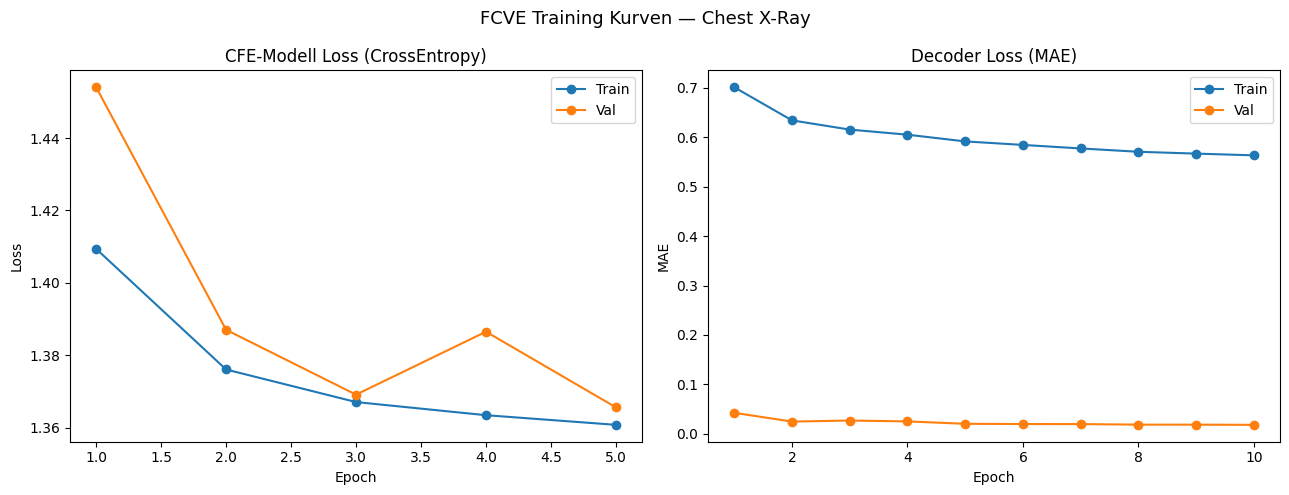

Trainingskurven gespeichert ✓


In [11]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(range(1, len(cfe_train_losses)+1), cfe_train_losses, 'o-', label='Train')
axes[0].plot(range(1, len(cfe_val_losses)+1),   cfe_val_losses,   'o-', label='Val')
axes[0].set_title('CFE-Modell Loss (CrossEntropy)')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()

axes[1].plot(range(1, len(dec_train_losses)+1), dec_train_losses, 'o-', label='Train')
axes[1].plot(range(1, len(dec_val_losses)+1),   dec_val_losses,   'o-', label='Val')
axes[1].set_title('Decoder Loss (MAE)')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('MAE')
axes[1].legend()

plt.suptitle('FCVE Training Kurven — Chest X-Ray', fontsize=13)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fcve_training_curves_xray.png'), dpi=120)
plt.show()
print('Trainingskurven gespeichert ✓')

## 11. Trainingskurven

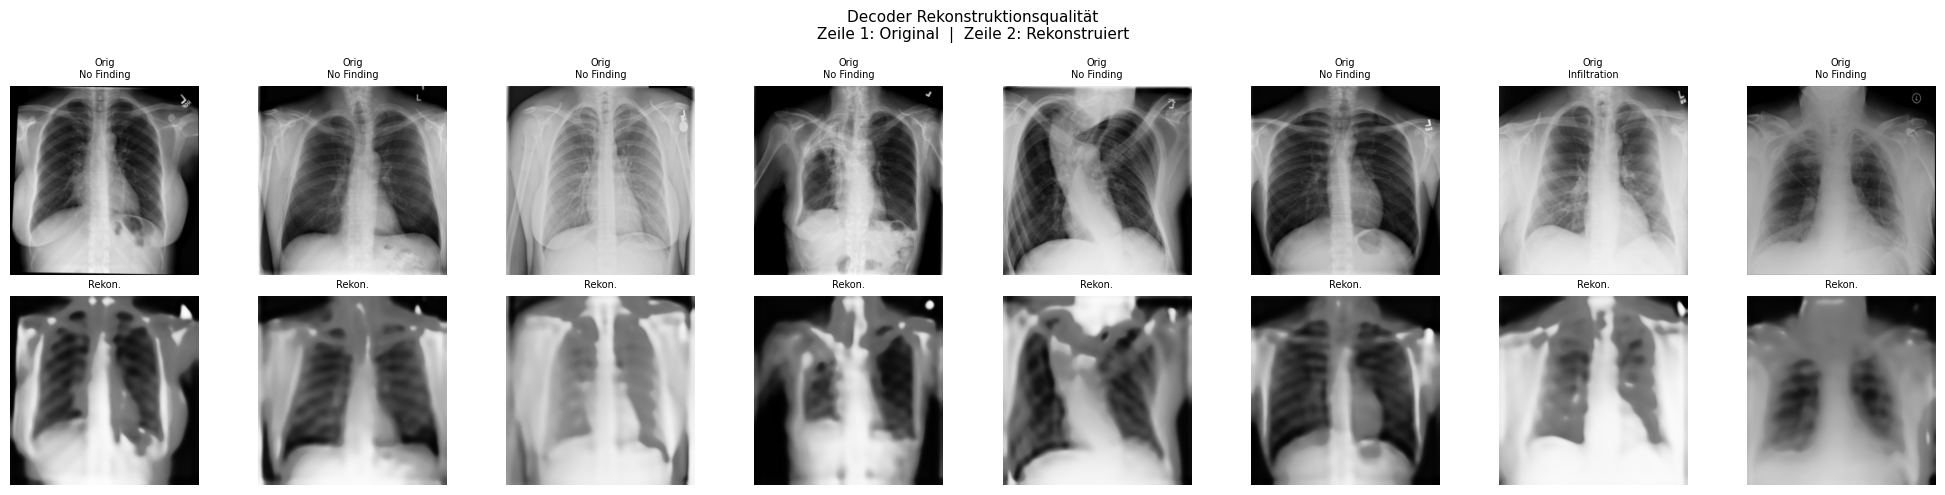

MAE auf Stichprobe: 0.0485  (niedriger = besser)

Alle Modelle gespeichert:
  /kaggle/working/fcve_cfe_model_xray.pth
  /kaggle/working/fcve_decoder_xray.pth
  /kaggle/working/fcve_training_curves_xray.png
  /kaggle/working/fcve_reconstruction_check_xray.png


In [12]:
def denormalise_cpu(tensor):
    """Funktioniert für 3D (C,H,W) und 4D (B,C,H,W) Tensoren."""
    if tensor.dim() == 3:
        mean = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1)
        std  = torch.tensor([0.5, 0.5, 0.5]).view(3,1,1)
    else:
        mean = torch.tensor([0.5, 0.5, 0.5]).view(1,3,1,1)
        std  = torch.tensor([0.5, 0.5, 0.5]).view(1,3,1,1)
    return (tensor * std + mean).clamp(0, 1)

decoder.eval()
sample_imgs, sample_lbls, _ = next(iter(test_loader))
sample_imgs = sample_imgs[:8].to(DEVICE)

with torch.no_grad():
    f1, f2, f3, f4, _ = extract_all_features(classifier, sample_imgs)
    cp = denormalise(sample_imgs).mean(dim=[2, 3])   # NEU
    recon = decoder(f4, f1, color_prior=cp)

fig, axes = plt.subplots(2, 8, figsize=(20, 5))
for i in range(8):
    orig_np  = denormalise_cpu(sample_imgs[i].cpu()).permute(1,2,0).numpy()
    recon_np = tanh_to_img(recon[i].detach().cpu()).permute(1,2,0).numpy().clip(0,1)

    axes[0, i].imshow(orig_np)
    axes[0, i].set_title(f'Orig\n{CLASS_NAMES[sample_lbls[i].item()]}', fontsize=7)
    axes[0, i].axis('off')

    axes[1, i].imshow(recon_np)
    axes[1, i].set_title('Rekon.', fontsize=7)
    axes[1, i].axis('off')

plt.suptitle('Decoder Rekonstruktionsqualität\nZeile 1: Original  |  Zeile 2: Rekonstruiert', fontsize=11)
plt.tight_layout()
plt.savefig(os.path.join(OUT_DIR, 'fcve_reconstruction_check_xray.png'), dpi=120)
plt.show()

mae_check = nn.L1Loss()(
    tanh_to_img(recon.detach().cpu()),
    denormalise_cpu(sample_imgs.cpu())
)
print(f'MAE auf Stichprobe: {mae_check.item():.4f}  (niedriger = besser)')
print('\nAlle Modelle gespeichert:')
print(f'  {OUT_DIR}/fcve_cfe_model_xray.pth')
print(f'  {OUT_DIR}/fcve_decoder_xray.pth')
print(f'  {OUT_DIR}/fcve_training_curves_xray.png')
print(f'  {OUT_DIR}/fcve_reconstruction_check_xray.png')

In [13]:
# ══════════════════════════════════════════════════════════════════════════════
# FCVE AUSWERTUNG & VISUALISIERUNG
# ══════════════════════════════════════════════════════════════════════════════

import matplotlib.patches as patches

def denormalise_vis(tensor):
    """Funktioniert für 3D (C,H,W) und 4D (B,C,H,W) Tensoren."""
    if tensor.dim() == 3:
        mean = torch.tensor(IMAGENET_MEAN, device=tensor.device).view(3,1,1)
        std  = torch.tensor(IMAGENET_STD,  device=tensor.device).view(3,1,1)
    else:
        mean = torch.tensor(IMAGENET_MEAN, device=tensor.device).view(1,3,1,1)
        std  = torch.tensor(IMAGENET_STD,  device=tensor.device).view(1,3,1,1)
    return (tensor * std + mean).clamp(0, 1)

def draw_bbox_on_ax(ax, bbox_dict, image_name, color='yellow', linewidth=2):
    if image_name not in bbox_dict:
        return False
    b = bbox_dict[image_name]
    rect = patches.Rectangle(
        (b['x'], b['y']), b['w'], b['h'],
        linewidth=linewidth, edgecolor=color,
        facecolor='none', linestyle='--'
    )
    ax.add_patch(rect)
    ax.text(b['x'], b['y'] - 4, 'GT BBox',
            color=color, fontsize=7, fontweight='bold',
            bbox=dict(facecolor='black', alpha=0.4, pad=1))
    return True


# bbox_lookup wurde bereits in Abschnitt 3 aus BBox_List_2017.csv geladen ✓
print(f'Infiltrate BBoxes verfügbar: {len(bbox_lookup)} Bilder')


# ── compute_fcve ──────────────────────────────────────────────────────────────
def compute_fcve(classifier, cfe_model, decoder, images, device):
    """
    Vollständige FCVE Pipeline für einen Batch.
    Rückgabe:
        cfe_images   : (B, 3, 224, 224) — generierte CFE-Bilder
        mc_filters   : (B, 512)
        mi_filters   : (B, 512)
        source_labels: (B,)
        cfe_labels   : (B,)
        orig_probs   : (B,)  — P(Klasse 1 = Infiltration) Original
        cfe_probs    : (B,)  — P(Klasse 1 = Infiltration) nach MI-Filter
    """
    classifier.eval()
    cfe_model.eval()
    decoder.eval()
    images = images.to(device)

    with torch.no_grad():
        f1, f2, f3, f4, z_gap = extract_all_features(classifier, images)

        logits        = classify_from_gap(classifier, z_gap)
        probs         = torch.softmax(logits, dim=1)
        orig_probs    = probs[:, 1]              # P(Infiltration) — konsistent mit Mirror
        source_labels = logits.argmax(dim=1)
        cfe_labels    = 1 - source_labels

        mc_filters, mi_filters = cfe_model(z_gap)

        # ── Paper Eq. 7: BEIDE Filter im GAP-Raum koppeln ─────────────────────
        #   MC (multiplikativ): nicht-klassenrelevante Konzepte erhalten
        #   MI (additiv):       klassenunterscheidende Konzepte verschieben
        z_cf      = apply_mi_filters(apply_mc_filters(z_gap, mc_filters), mi_filters)
        logits_cf = classify_from_gap(classifier, z_cf)
        probs_cf  = torch.softmax(logits_cf, dim=1)
        cfe_probs = probs_cf[:, 1]               # P(Infiltration) nach MC+MI

        # ── Spatiale Map konsistent zum modifizierten GAP-Vektor machen ───────
        #   f4_modified = f4 * MC + MI (pro Kanal), sodass GAP(f4_modified) = z_cf.
        #   So tragen das GENERIERTE Bild und das GEMESSENE Flip-Signal dieselbe
        #   Information (Korrektur Schritt 1+3).
        # Skip-frei (Eq. 8): das Bild entsteht ALLEIN aus dem modifizierten
        # Vektor z_cf (auf 7x7 gebroadcastet) — strukturgleich zum Training.
        f4_cf      = z_cf.view(-1, 512, 1, 1).expand(-1, 512, 7, 7).contiguous()
        f4_base    = z_gap.view(-1, 512, 1, 1).expand(-1, 512, 7, 7).contiguous()
        img01      = denormalise(images)
        cp         = img01.mean(dim=[2, 3])
        recon_base = decoder(f4_base, f1, color_prior=cp)
        recon_cf   = decoder(f4_cf,   f1, color_prior=cp)
        # RESIDUAL-COMPOSITING: Decoder-Artefakte (Tint/Blur/Rand) stecken in
        # BEIDEN Decodings und heben sich im Delta auf; Shrinkage nullt
        # Restrauschen (identisch zum Training, s. Decoder-Trainingszelle).
        delta      = shrink_delta(tanh_to_img(recon_cf) - tanh_to_img(recon_base))
        comp       = (img01 + delta).clamp(0, 1)
        cfe_images = comp * 2.0 - 1.0   # zurueck in Tanh-Domaene (Downstream-Kompatibilitaet)

    return cfe_images, mc_filters, mi_filters, source_labels, cfe_labels, orig_probs, cfe_probs


# ── get_cfe_image_from_fcve ───────────────────────────────────────────────────
def get_cfe_image_from_fcve(classifier, cfe_model, decoder, images):
    """
    Generiert CFE-Bilder als numpy arrays für Metrik-Berechnung.
    Rückgabe: orig_np, cfe_np — beide (B, H, W, 3) in [0,1]
    """
    images = images.to(DEVICE)
    (cfe_imgs, _, _, _, c_lbls, _, cfe_p) = compute_fcve(
        classifier, cfe_model, decoder, images, DEVICE
    )
    orig_np = denormalise_vis(images.cpu()).permute(0,2,3,1).numpy()
    cfe_np  = tanh_to_img(cfe_imgs.detach().cpu()).permute(0,2,3,1).numpy().clip(0,1)
    return orig_np, cfe_np


# ── Visualisierungsfunktion ───────────────────────────────────────────────────
def visualise_fcve(classifier, cfe_model, decoder,
                   images, labels, fnames,
                   cfe_imgs, mc_filt, mi_filt,
                   src_lbls, cfe_lbls, orig_p, cfe_p,
                   bbox_lookup, class_names,
                   bbox_class_idx=1, bbox_color='yellow',
                   n_samples=4, save_path='fcve.png'):
    """
    Drei-Panel Visualisierung pro Sample (identisch mit Mirror & CFProto):
      Panel 1: Original xᵢ + GT BBox
      Panel 2: CFE x' (Decoder Output)
      Panel 3: Differenzbild |x' − xᵢ|
    """
    images = images.to(DEVICE)
    n      = min(n_samples, images.size(0))

    orig_p_np = orig_p[:n].cpu().numpy()
    cfe_p_np  = cfe_p[:n].cpu().numpy()

    fig, axes = plt.subplots(n, 3, figsize=(13, n * 4.5))
    if n == 1:
        axes = axes[np.newaxis, :]

    col_titles = ['Original xᵢ + GT BBox', "CFE x' (Decoder)", "|x' − xᵢ| Differenz"]
    for col, title in enumerate(col_titles):
        axes[0, col].set_title(title, fontsize=10, fontweight='bold', pad=10)

    for i in range(n):
        orig_np = denormalise_vis(images[i].cpu()).permute(1,2,0).numpy()
        cfe_np  = tanh_to_img(cfe_imgs[i].detach().cpu()).permute(1,2,0).numpy().clip(0,1)
        diff_np = np.abs(cfe_np - orig_np).mean(axis=2)
        diff_np = (diff_np - diff_np.min()) / (diff_np.max() + 1e-8)

        src_lbl  = src_lbls[i].item()
        cfe_lbl  = cfe_lbls[i].item()
        true_lbl = int(labels[i])
        fname    = fnames[i]
        flipped  = int(cfe_p_np[i] >= 0.5) == cfe_lbl
        has_bbox = fname in bbox_lookup

        flip_col = 'limegreen' if flipped else 'tomato'
        flip_txt = '✓ Gekippt' if flipped else '✗ Nicht gekippt'
        pred_col = 'limegreen' if src_lbl == true_lbl else 'tomato'

        # ── Panel 1: Original + BBox ──────────────────────────────────────────
        ax1 = axes[i, 0]
        ax1.imshow(orig_np)
        if has_bbox and true_lbl == bbox_class_idx:
            draw_bbox_on_ax(ax1, bbox_lookup, fname, color=bbox_color)
        ax1.set_ylabel(
            f'Wahr: {class_names[true_lbl]}\n'
            f'Pred: {class_names[src_lbl]} ({orig_p_np[i]:.1%})',
            fontsize=8, color=pred_col, rotation=0,
            labelpad=100, va='center'
        )
        ax1.axis('off')

        # ── Panel 2: CFE-Bild ─────────────────────────────────────────────────
        ax2 = axes[i, 1]
        ax2.imshow(cfe_np)
        ax2.set_xlabel(
            f'Ziel: {class_names[cfe_lbl]} ({cfe_p_np[i]:.1%})\n{flip_txt}',
            fontsize=8, color=flip_col
        )
        ax2.axis('off')

        # ── Panel 3: Differenzbild ────────────────────────────────────────────
        ax3 = axes[i, 2]
        im  = ax3.imshow(diff_np, cmap='hot', vmin=0, vmax=1)
        plt.colorbar(im, ax=ax3, fraction=0.046, pad=0.04)
        if has_bbox and true_lbl == bbox_class_idx:
            draw_bbox_on_ax(ax3, bbox_lookup, fname, color='cyan', linewidth=1)
        ax3.axis('off')

    plt.suptitle(
        "FCVE-CFE + Decoder: Original xᵢ  |  CFE x'  |  Differenz |x' − xᵢ|\n"
        "Grün = Vorhersage gekippt  |  Rot = Vorhersage nicht gekippt",
        fontsize=11, y=1.01
    )
    plt.tight_layout()
    plt.savefig(save_path, dpi=120, bbox_inches='tight')
    plt.show()
    print(f'Gespeichert → {save_path}')


print('FCVE Visualisierungsfunktionen definiert ✓')


Infiltrate BBoxes verfügbar: 123 Bilder
FCVE Visualisierungsfunktionen definiert ✓


In [14]:
# ── Sanity Check — Flip Rate ──────────────────────────────────────────────────
sample_imgs_fcve, sample_lbls_fcve, sample_fnames_fcve = next(iter(test_loader))

(cfe_imgs, mc_filt, mi_filt,
 src_lbls, cfe_lbls, orig_p, cfe_p) = compute_fcve(
    classifier, cfe_model, decoder,
    sample_imgs_fcve, DEVICE
)

cfe_preds = (cfe_p >= 0.5).long().cpu()
flip_rate = (cfe_preds == cfe_lbls.cpu()).float().mean()

print(f'Batch-Größe   : {len(sample_lbls_fcve)}')
print(f'Flip Rate     : {flip_rate:.2%}  (Ziel: >60%)')
print(f'Quellvorhers. : {src_lbls.tolist()}')
print(f'CFE-Vorhers.  : {cfe_preds.tolist()}')
print(f'Zielklassen   : {cfe_lbls.tolist()}')
bbox_count = sum(1 for f in sample_fnames_fcve if f in bbox_lookup)
print(f'Bilder mit BBox: {bbox_count}/{len(sample_fnames_fcve)}')
if flip_rate < 0.6:
    print('\n⚠ Flip Rate niedrig — CFE-Modell neu trainieren oder Hyperparameter anpassen')


Batch-Größe   : 16
Flip Rate     : 93.75%  (Ziel: >60%)
Quellvorhers. : [1, 0, 1, 0, 1, 1, 1, 1, 0, 1, 0, 1, 1, 1, 1, 0]
CFE-Vorhers.  : [0, 1, 0, 1, 1, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1]
Zielklassen   : [0, 1, 0, 1, 0, 0, 0, 0, 1, 0, 1, 0, 0, 0, 0, 1]
Bilder mit BBox: 0/16


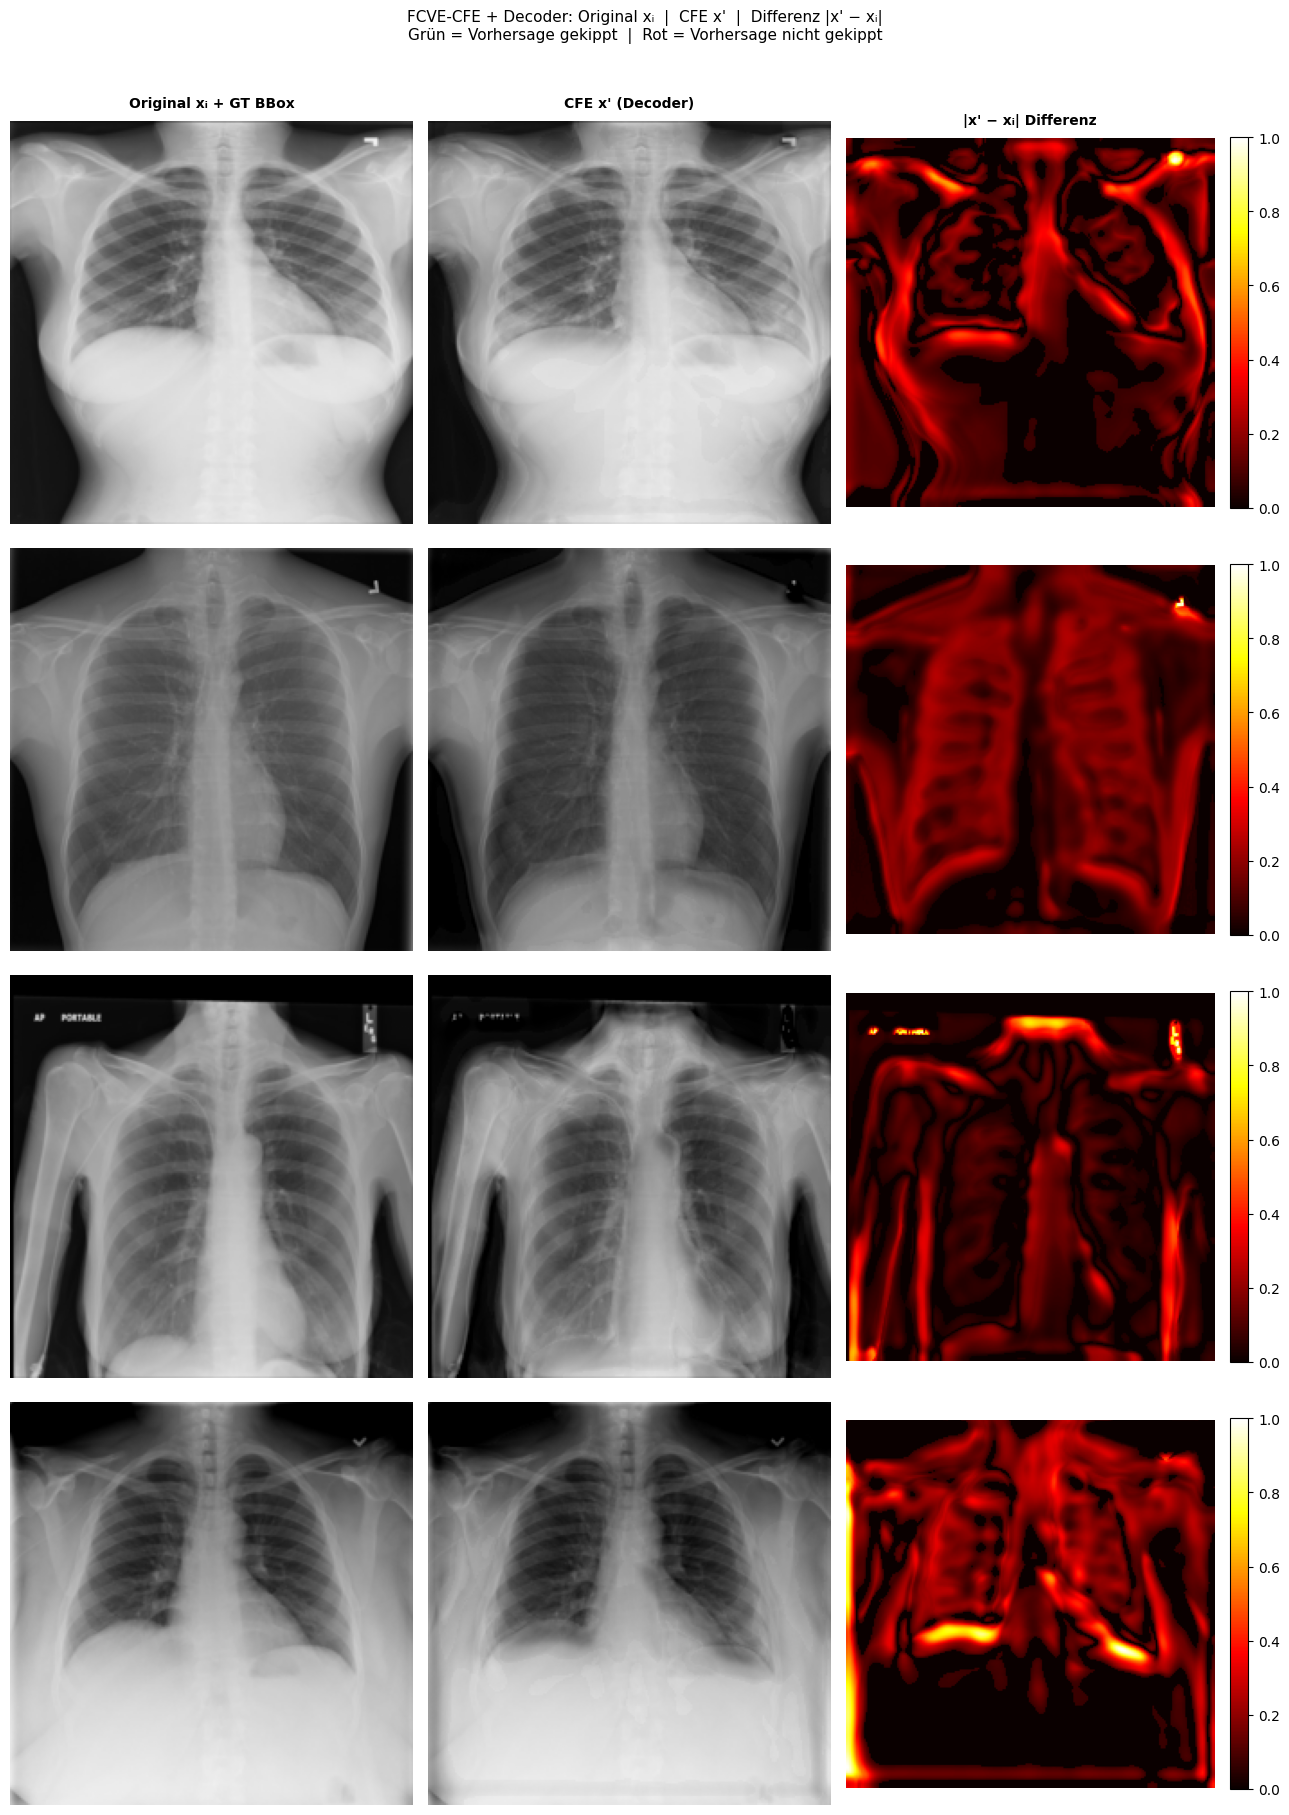

Gespeichert → /kaggle/working/fcve_xray.png


In [15]:
# ── Visualisierung mit Random Val-Batch ──────────────────────────────────────
visualise_fcve(
    classifier    = classifier,
    cfe_model     = cfe_model,
    decoder       = decoder,
    images        = sample_imgs_fcve,
    labels        = sample_lbls_fcve,
    fnames        = sample_fnames_fcve,
    cfe_imgs      = cfe_imgs,
    mc_filt       = mc_filt,
    mi_filt       = mi_filt,
    src_lbls      = src_lbls,
    cfe_lbls      = cfe_lbls,
    orig_p        = orig_p,
    cfe_p         = cfe_p,
    bbox_lookup   = bbox_lookup,
    class_names   = CLASS_NAMES,
    bbox_class_idx = 1,   # Infiltration (1) hat BBoxen
    bbox_color    = 'yellow',
    n_samples     = 4,
    save_path     = '/kaggle/working/fcve_xray.png'
)


Infiltration-Bilder mit BBox im Test-Set: 11


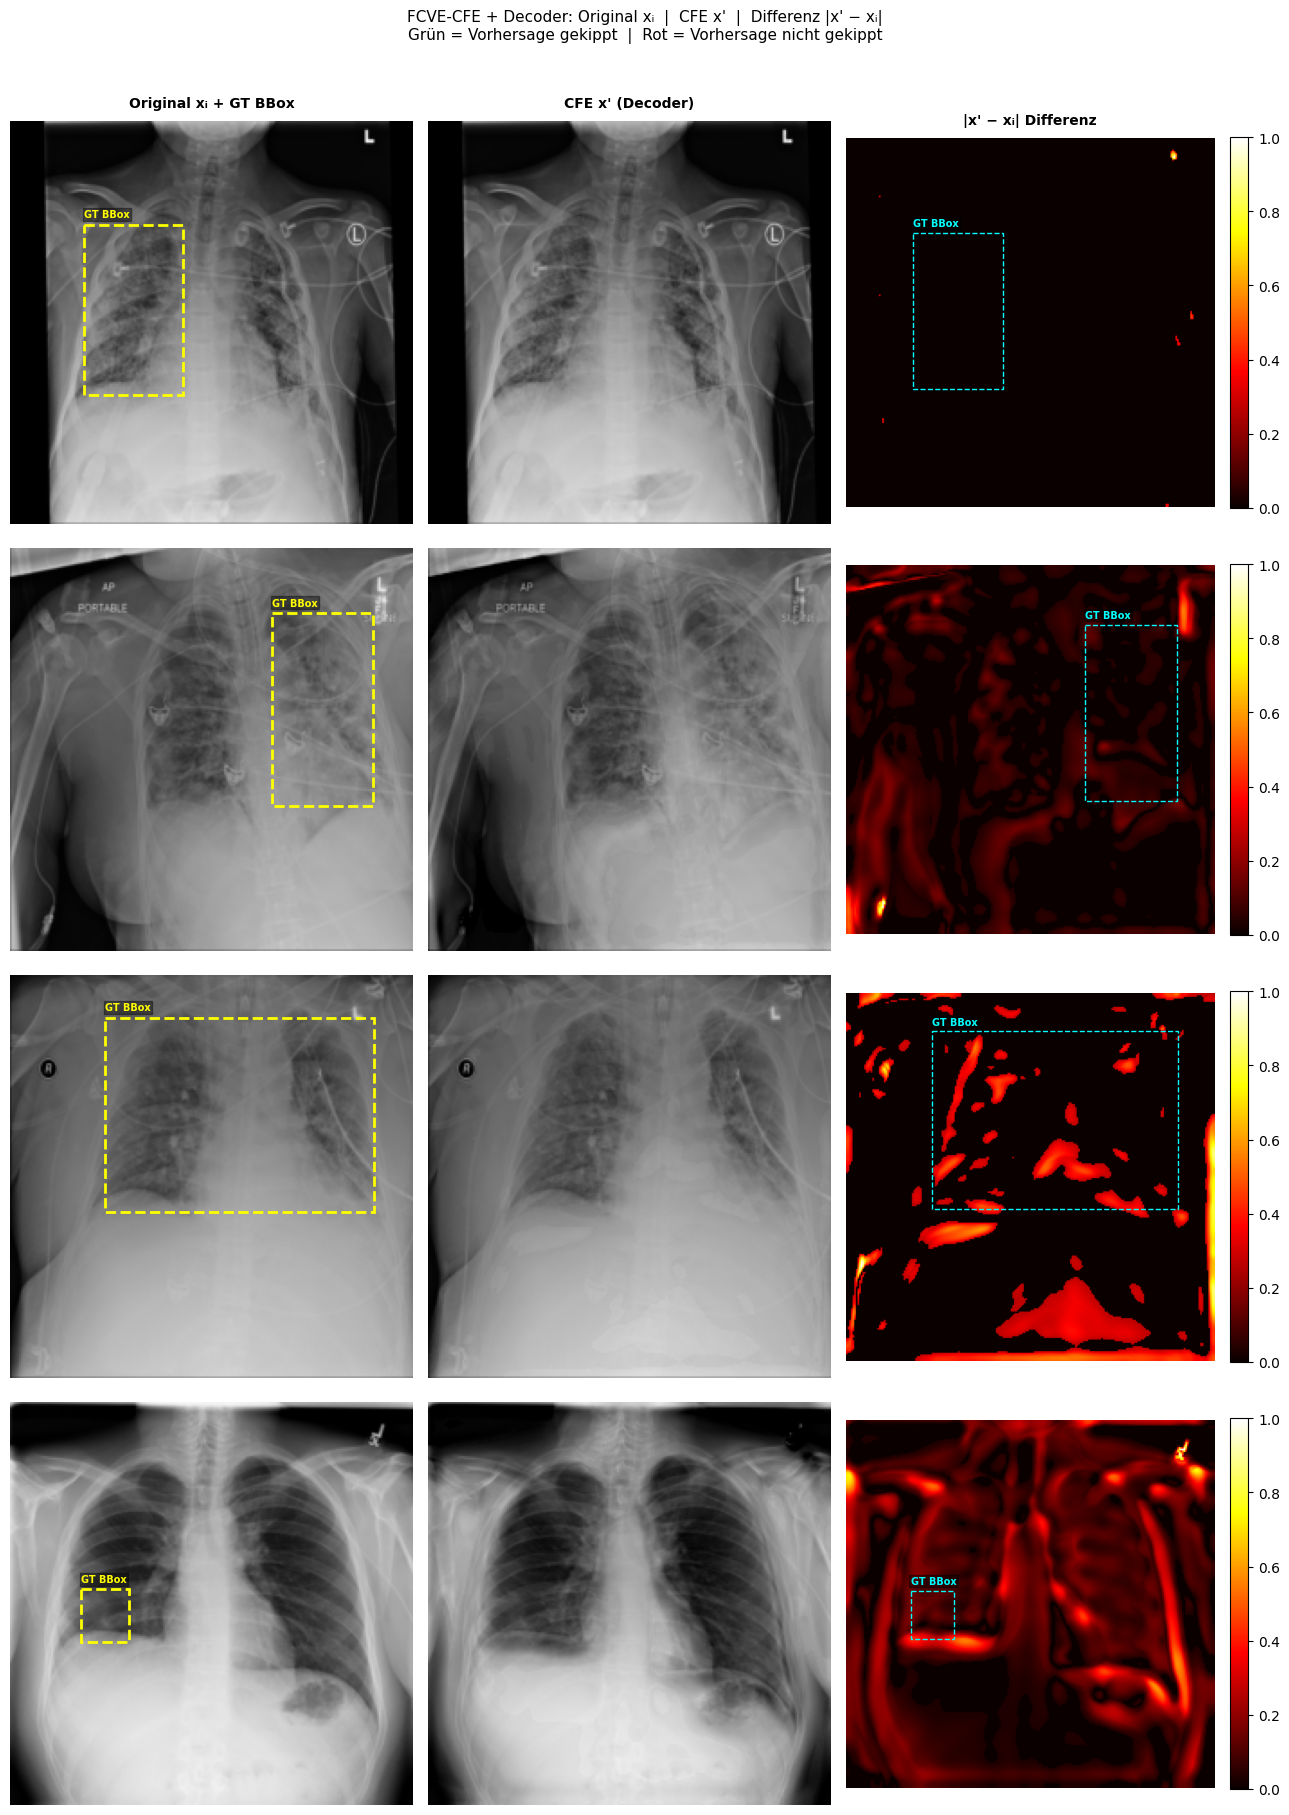

Gespeichert → /kaggle/working/fcve_xray_bbox.png


In [16]:
# ── Infiltration-Bilder mit BBox (Test-Set) ──────────────────────────────────
bbox_image_names = set(bbox_lookup.keys())
test_with_bbox = test_df[
    (test_df['binary_label'] == 1) &
    (test_df['Image Index'].isin(bbox_image_names))
].reset_index(drop=True)

print(f'Infiltration-Bilder mit BBox im Test-Set: {len(test_with_bbox)}')

if len(test_with_bbox) == 0:
    test_with_bbox = all_xray_df[
        (all_xray_df['binary_label'] == 1) &
        (all_xray_df['Image Index'].isin(bbox_image_names))
    ].reset_index(drop=True)
    print(f'Verwende alle verfügbaren BBox-Bilder: {len(test_with_bbox)}')

bbox_dataset    = XRayDataset(test_with_bbox, transform=eval_transforms)
bbox_loader_vis = DataLoader(bbox_dataset, batch_size=8, shuffle=True,
                              num_workers=2, pin_memory=False)
bbox_imgs, bbox_lbls, bbox_fnames_b = next(iter(bbox_loader_vis))

(xcf_b_bbox, mc_b, mi_b,
 src_b_bbox, cfe_b_bbox, prob_b_bbox, cp_b) = compute_fcve(
    classifier, cfe_model, decoder, bbox_imgs, DEVICE
)

visualise_fcve(
    classifier    = classifier,
    cfe_model     = cfe_model,
    decoder       = decoder,
    images        = bbox_imgs,
    labels        = bbox_lbls,
    fnames        = bbox_fnames_b,
    cfe_imgs      = xcf_b_bbox,
    mc_filt       = mc_b,
    mi_filt       = mi_b,
    src_lbls      = src_b_bbox,
    cfe_lbls      = cfe_b_bbox,
    orig_p        = prob_b_bbox,
    cfe_p         = cp_b,
    bbox_lookup   = bbox_lookup,
    class_names   = CLASS_NAMES,
    bbox_class_idx = 1,
    bbox_color    = 'yellow',
    n_samples     = 4,
    save_path     = '/kaggle/working/fcve_xray_bbox.png'
)


In [17]:
# ── Batch-Evaluation — Flip Rate über 10 Batches ─────────────────────────────
total_flip   = 0
total_images = 0

for batch_imgs, batch_lbls, batch_fnames in tqdm(
        list(test_loader)[:10], desc='FCVE Evaluation'):
    (b_cfe, _, _, b_src, b_cfe_lbl, _, b_cp) = compute_fcve(
        classifier, cfe_model, decoder, batch_imgs, DEVICE
    )
    preds        = (b_cp >= 0.5).long().cpu()
    total_flip   += (preds == b_cfe_lbl.cpu()).sum().item()
    total_images += len(batch_lbls)

print(f'\nFlip Rate: {total_flip}/{total_images} = {total_flip/total_images:.2%}')


FCVE Evaluation: 100%|██████████| 10/10 [00:00<00:00, 11.07it/s]


Flip Rate: 145/160 = 90.62%


## Metriken

In [18]:
pip install lpips

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 53.8/53.8 kB 1.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.2/12.2 MB 88.9 MB/s eta 0:00:00
  Attempting uninstall: cuda-bindings
    Found existing installation: cuda-bindings 13.2.0
    Uninstalling cuda-bindings-13.2.0:
      Successfully uninstalled cuda-bindings-13.2.0
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dask-cuda 26.2.0 requires cuda-core==0.3.*, but you have cuda-core 1.0.1 which is incompatible.
dask-cuda 26.2.0 requires numba-cuda<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
distributed-ucxx-cu12 0.48.0 requires numba-cuda[cu12]<0.23.0,>=0.22.1, but you have numba-cuda 0.30.2 which is incompatible.
cuml-cu12 26.2.0 requires numba<0.62.0,>=0.60.0, but you have numba 0.65.1 which is incompatible.
cuml-cu12 26.2.0 requires numba-cuda[cu12]<0.23.0,>=0.22.

In [19]:
# ══════════════════════════════════════════════════════════════════════════════
# METRIKEN — identisch mit Mirror-CFE & CFProto für direkten Vergleich
# ══════════════════════════════════════════════════════════════════════════════
import time
from scipy import linalg as scipy_linalg

try:
    import lpips
    lpips_fn = lpips.LPIPS(net='squeeze').to(DEVICE)
    lpips_fn.eval()
    LPIPS_AVAILABLE = True
    print('LPIPS geladen ✓')
except ImportError:
    LPIPS_AVAILABLE = False
    print('⚠ lpips nicht verfügbar — pip install lpips')


# ── 1. L1-Distanz (Proximity) ─────────────────────────────────────────────────
def compute_l1(orig_np, cfe_np):
    """L1-Norm nach Wachter et al. (2017). Niedrigerer Wert = näher am Original."""
    diffs = np.abs(orig_np - cfe_np)
    l1_per_sample = diffs.sum(axis=(1,2,3)) / (orig_np.shape[1] * orig_np.shape[2] * orig_np.shape[3])
    return float(l1_per_sample.mean())


# ── 2. Sparsity Rate (Interpretierbarkeit) ────────────────────────────────────
def compute_sparsity_rate(orig_np, cfe_np, threshold=1e-4):
    """Anteil der veränderten Pixel nach Moreira et al. (2025)."""
    diff = np.abs(orig_np - cfe_np).mean(axis=-1)
    changed = (diff > threshold).astype(float)
    return float(changed.mean(axis=(1,2)).mean())


# ── 3. LPIPS (Interpretierbarkeit / Perceptual Similarity) ───────────────────
def compute_lpips(orig_np, cfe_np):
    """LPIPS nach Zhang et al. (2018) mit SqueezeNet."""
    if not LPIPS_AVAILABLE:
        return None
    orig_t = torch.tensor(orig_np, dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    cfe_t  = torch.tensor(cfe_np,  dtype=torch.float32).permute(0,3,1,2).to(DEVICE) * 2 - 1
    with torch.no_grad():
        scores = lpips_fn(orig_t, cfe_t)
    return float(scores.mean().cpu())


# ── 4. FID (Plausibilität) — InceptionV3 Features ────────────────────────────
from torchvision.models import inception_v3

@torch.no_grad()
def extract_inception_features(imgs_np, batch_size=32):
    """Extrahiert 2048-dim InceptionV3 Features. imgs_np: (B, H, W, 3) in [0,1]"""
    if not hasattr(extract_inception_features, '_model'):
        model_inc = inception_v3(weights='DEFAULT', transform_input=False)
        model_inc.fc = nn.Identity()
        model_inc = model_inc.eval().to(DEVICE)
        extract_inception_features._model = model_inc
    inc   = extract_inception_features._model
    feats = []
    for i in range(0, len(imgs_np), batch_size):
        batch = imgs_np[i:i+batch_size]
        t = torch.tensor(batch, dtype=torch.float32).permute(0,3,1,2).to(DEVICE)
        t = torch.nn.functional.interpolate(t, size=(299,299), mode='bilinear',
                                             align_corners=False)
        feats.append(inc(t).cpu().numpy())
    return np.concatenate(feats, axis=0)


def compute_fid(real_np, fake_np):
    """FID über InceptionV3 Features. Niedrigerer Wert = plausibler."""
    real_feats = extract_inception_features(real_np)
    fake_feats = extract_inception_features(fake_np)
    mu_r, mu_f = real_feats.mean(0), fake_feats.mean(0)
    sig_r = np.cov(real_feats, rowvar=False)
    sig_f = np.cov(fake_feats, rowvar=False)
    diff     = mu_r - mu_f
    covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)
    if np.iscomplexobj(covmean):
        covmean = covmean.real
    return float(diff @ diff + np.trace(sig_r + sig_f - 2 * covmean))


# ── 5. EBPG (Lokalisierung, nur bei BBox-Bildern) ────────────────────────────
def compute_ebpg(orig_np, cfe_np, bboxes_pixel):
    """Energy-Based Pointing Game nach Wang et al. (2019)."""
    scores = []
    for i, bbox in enumerate(bboxes_pixel):
        diff = np.abs(cfe_np[i] - orig_np[i]).mean(axis=-1)
        total_energy = diff.sum() + 1e-8
        x1 = max(0, int(bbox['x']))
        y1 = max(0, int(bbox['y']))
        x2 = min(224, int(bbox['x'] + bbox['w']))
        y2 = min(224, int(bbox['y'] + bbox['h']))
        scores.append(diff[y1:y2, x1:x2].sum() / total_energy)
    return float(np.mean(scores)) if scores else None


# ── 6. Validity & Denoised Validity (Funktionalität) ─────────────────────────
def compute_validity(model, cfe_imgs_tensor, cfe_labels, denoise_sigma=None):
    """Validity nach Verma et al. (2022). Misst Klassenflip im Pixelraum."""
    from torchvision.transforms.functional import gaussian_blur
    model.eval()
    cfe_imgs_tensor = cfe_imgs_tensor.to(DEVICE)
    if denoise_sigma is not None:
        kernel_size = max(int(denoise_sigma * 6) | 1, 3)
        cfe_imgs_tensor = gaussian_blur(cfe_imgs_tensor,
                                        kernel_size=[kernel_size, kernel_size],
                                        sigma=[denoise_sigma, denoise_sigma])
    mean = torch.tensor(IMAGENET_MEAN, device=DEVICE).view(1,3,1,1)
    std  = torch.tensor(IMAGENET_STD,  device=DEVICE).view(1,3,1,1)
    cfe_norm = (cfe_imgs_tensor - mean) / std
    with torch.no_grad():
        preds = model(cfe_norm).argmax(dim=1).cpu()
    return float((preds == cfe_labels.cpu()).float().mean())


# ── 7. Coverage (Funktionalität) ──────────────────────────────────────────────
def compute_coverage(classifier, cfe_model, decoder, images, n_runs=5):
    """Coverage nach Moreira et al. (2025): wie oft findet FCVE ein valides CF?"""
    images = images.to(DEVICE)
    valid_runs = []
    for run in range(n_runs):
        torch.manual_seed(run)
        (_, _, _, _, c_lbls, _, cfe_p) = compute_fcve(
            classifier, cfe_model, decoder, images, DEVICE
        )
        preds = (cfe_p >= 0.5).long().cpu()
        rate  = (preds == c_lbls.cpu()).float().mean().item()
        valid_runs.append(rate)
    return float(np.mean(valid_runs)), float(np.std(valid_runs))


print('Metrik-Funktionen definiert ✓')


/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=SqueezeNet1_1_Weights.IMAGENET1K_V1`. You can also use `weights=SqueezeNet1_1_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)


Setting up [LPIPS] perceptual loss: trunk [squeeze], v[0.1], spatial [off]
Downloading: "https://download.pytorch.org/models/squeezenet1_1-b8a52dc0.pth" to /root/.cache/torch/hub/checkpoints/squeezenet1_1-b8a52dc0.pth


100%|██████████| 4.73M/4.73M [00:00<00:00, 68.0MB/s]

Loading model from: /usr/local/lib/python3.12/dist-packages/lpips/weights/v0.1/squeeze.pth
LPIPS geladen ✓
Metrik-Funktionen definiert ✓


## Metriken berechnen

In [20]:
# ══════════════════════════════════════════════════════════════════════════════
# FESTER EVAL-SATZ — einheitlich über ALLE Methoden (Seed + BBox-Garantie)
# ══════════════════════════════════════════════════════════════════════════════
# Garantiert, dass jede CF-Methode auf EXAKT denselben 80 Bildern evaluiert und
# EBPG nie leer ist. Die Hälfte sind (sofern verfügbar) BBox-Bilder der Zielklasse.
# Auswahl & Reihenfolge sind über EVAL_SEED reproduzierbar und notebook-übergreifend
# identisch (gleicher test_df, gleicher Seed → gleiche Bilder).

EVAL_SEED     = 42
N_EVAL_IMAGES = 80
TARGET_CLASS  = 1   # Zielklasse mit BBoxen

_idx_all  = list(range(len(test_df)))
_idx_bbox = [i for i in _idx_all
             if int(test_df.iloc[i]['binary_label']) == TARGET_CLASS
             and test_df.iloc[i]['Image Index'] in bbox_lookup]
_idx_rest = [i for i in _idx_all if i not in set(_idx_bbox)]

_rng = np.random.RandomState(EVAL_SEED)
_rng.shuffle(_idx_bbox)
_rng.shuffle(_idx_rest)

_n_bbox = min(len(_idx_bbox), N_EVAL_IMAGES // 2)
_sel    = _idx_bbox[:_n_bbox] + _idx_rest[:(N_EVAL_IMAGES - _n_bbox)]
_rng2   = np.random.RandomState(EVAL_SEED)
_rng2.shuffle(_sel)
eval_indices = _sel[:N_EVAL_IMAGES]

eval_df      = test_df.iloc[eval_indices].reset_index(drop=True)
eval_dataset = XRayDataset(eval_df, transform=eval_transforms)
eval_loader  = DataLoader(eval_dataset, batch_size=BATCH_SIZE,
                          shuffle=False, num_workers=2, pin_memory=False)

_n_tgt = int((eval_df['binary_label'] == TARGET_CLASS).sum())
_n_bbx = sum(1 for _, r in eval_df.iterrows()
             if r['Image Index'] in bbox_lookup and int(r['binary_label']) == TARGET_CLASS)
print(f'Fester Eval-Satz: {len(eval_df)} Bilder (Seed {EVAL_SEED})')
print(f'  Zielklasse:        {_n_tgt}')
print(f'  davon mit BBox:    {_n_bbx}  → EBPG-Stichprobe')


Fester Eval-Satz: 80 Bilder (Seed 42)
  Zielklasse:        25
  davon mit BBox:    11  → EBPG-Stichprobe


In [21]:
# ══════════════════════════════════════════════════════════════════════════════
# METRIKEN BERECHNEN — über 5 Batches (identisch mit Mirror & CFProto)
# ══════════════════════════════════════════════════════════════════════════════

N_EVAL_BATCHES = 5
DENOISE_SIGMA  = 1.0

all_l1, all_sparsity, all_lpips = [], [], []
all_real_np, all_cfe_np = [], []
all_eval_imgs = []          # für Coverage über vollen Eval-Satz
all_cfe_tensor, all_cfe_labels = [], []
all_ebpg = []
total_time = 0.0
n_images   = 0

print(f'Berechne Metriken über {len(eval_dataset)} Bilder (fester Eval-Satz)...')
print('-' * 60)

for batch_imgs, batch_lbls, batch_fnames in tqdm(
        eval_loader, desc='Metrik-Evaluation'):

    t0 = time.time()
    (b_cfe, _, _, b_src, b_cfe_lbl, _, b_cp) = compute_fcve(
        classifier, cfe_model, decoder, batch_imgs, DEVICE
    )
    total_time += time.time() - t0
    n_images   += len(batch_lbls)
    all_eval_imgs.append(batch_imgs.cpu())

    # CFE-Bilder als numpy (direkt aus bereits berechneten b_cfe)
    orig_np = denormalise_vis(batch_imgs).permute(0,2,3,1).numpy()
    cfe_np  = tanh_to_img(b_cfe.detach().cpu()).permute(0,2,3,1).numpy().clip(0,1)

    all_l1.append(compute_l1(orig_np, cfe_np))
    all_sparsity.append(compute_sparsity_rate(orig_np, cfe_np))

    if LPIPS_AVAILABLE:
        all_lpips.append(compute_lpips(orig_np, cfe_np))

    all_real_np.append(orig_np)
    all_cfe_np.append(cfe_np)

    cfe_t = torch.tensor(cfe_np, dtype=torch.float32).permute(0,3,1,2)
    all_cfe_tensor.append(cfe_t)
    all_cfe_labels.append(b_cfe_lbl.cpu())

    # EBPG — nur für Infiltration-Bilder (label 1) mit BBox
    batch_bboxes = []
    batch_valid  = []
    for i, fname in enumerate(batch_fnames):
        if fname in bbox_lookup and int(batch_lbls[i]) == 1:
            batch_bboxes.append(bbox_lookup[fname])
            batch_valid.append(i)
    if batch_bboxes:
        ebpg = compute_ebpg(orig_np[batch_valid], cfe_np[batch_valid], batch_bboxes)
        if ebpg is not None:
            all_ebpg.append(ebpg)

# ── FID ───────────────────────────────────────────────────────────────────────
real_all  = np.concatenate(all_real_np, axis=0)
cfe_all   = np.concatenate(all_cfe_np,  axis=0)
fid_score = compute_fid(real_all, cfe_all)

# ── Validity & Denoised Validity ─────────────────────────────────────────────
all_cfe_tensor_cat = torch.cat(all_cfe_tensor, dim=0)
all_cfe_labels_cat = torch.cat(all_cfe_labels, dim=0)

validity          = compute_validity(classifier, all_cfe_tensor_cat, all_cfe_labels_cat)
denoised_validity = compute_validity(classifier, all_cfe_tensor_cat, all_cfe_labels_cat,
                                     denoise_sigma=DENOISE_SIGMA)

# ── Coverage ──────────────────────────────────────────────────────────────────
print('Berechne Coverage (5 Runs über den festen Eval-Satz)...')
eval_imgs_cat = torch.cat(all_eval_imgs, dim=0)
coverage_mean, coverage_std = compute_coverage(
    classifier, cfe_model, decoder, eval_imgs_cat, n_runs=5
)

# ── Efficiency ────────────────────────────────────────────────────────────────
efficiency = total_time / n_images

print('\n' + '═' * 60)
print('METRIK-ERGEBNISSE — FCVE-CFE Chest X-Ray')
print('═' * 60)
print(f'\n── Proximity ───────────────────────────────────────────')
print(f'  L1-Distanz:           {np.mean(all_l1):.4f}  (↓ besser)')

print(f'\n── Interpretierbarkeit ─────────────────────────────────')
print(f'  Sparsity Rate:        {np.mean(all_sparsity):.4f}  (↓ besser)')
if LPIPS_AVAILABLE:
    print(f'  LPIPS (SqueezeNet):   {np.mean(all_lpips):.4f}  (↓ besser)')
else:
    print(f'  LPIPS:                nicht verfügbar')

print(f'\n── Plausibilität ───────────────────────────────────────')
print(f'  FID:                  {fid_score:.2f}   (↓ besser)')

if all_ebpg:
    print(f'\n── Lokalisierung (BBox-Bilder) ─────────────────────────')
    print(f'  EBPG:                 {np.mean(all_ebpg):.4f}  (↑ besser)')
    print(f'  Anzahl BBox-Samples (Batches): {len(all_ebpg)}')

print(f'\n── Funktionalität ──────────────────────────────────────')
print(f'  Validity:             {validity:.2%}  (↑ besser)')
print(f'  Denoised Validity:    {denoised_validity:.2%}  (↑ besser, σ={DENOISE_SIGMA})')
print(f'  Δ Validity:           {validity - denoised_validity:.2%}  (↓ besser = weniger adversarial)')
print(f'  Coverage:             {coverage_mean:.2%} ± {coverage_std:.2%}  (↑ besser)')
print(f'  Efficiency:           {efficiency:.3f}s / CF  (↓ besser)')
print('═' * 60)


Berechne Metriken über 80 Bilder (fester Eval-Satz)...
------------------------------------------------------------


Metrik-Evaluation: 100%|██████████| 5/5 [00:01<00:00,  3.02it/s]


Downloading: "https://download.pytorch.org/models/inception_v3_google-0cc3c7bd.pth" to /root/.cache/torch/hub/checkpoints/inception_v3_google-0cc3c7bd.pth


100%|██████████| 104M/104M [00:00<00:00, 189MB/s] 
/tmp/ipykernel_23/92615007.py:76: DeprecationWarning: The `disp` argument is deprecated and will be removed in SciPy 1.18.0.
  covmean, _ = scipy_linalg.sqrtm(sig_r @ sig_f, disp=False)


Berechne Coverage (5 Runs über den festen Eval-Satz)...

════════════════════════════════════════════════════════════
METRIK-ERGEBNISSE — FCVE-CFE Chest X-Ray
════════════════════════════════════════════════════════════

── Proximity ───────────────────────────────────────────
  L1-Distanz:           0.0476  (↓ besser)

── Interpretierbarkeit ─────────────────────────────────
  Sparsity Rate:        0.5451  (↓ besser)
  LPIPS (SqueezeNet):   0.0723  (↓ besser)

── Plausibilität ───────────────────────────────────────
  FID:                  65.70   (↓ besser)

── Lokalisierung (BBox-Bilder) ─────────────────────────
  EBPG:                 0.0374  (↑ besser)
  Anzahl BBox-Samples (Batches): 4

── Funktionalität ──────────────────────────────────────
  Validity:             51.25%  (↑ besser)
  Denoised Validity:    47.50%  (↑ besser, σ=1.0)
  Δ Validity:           3.75%  (↓ besser = weniger adversarial)
  Coverage:             97.50% ± 0.00%  (↑ besser)
  Efficiency:           0.002s /